# 2.Deliverable

## Part 1: CIFAR-10 Image Classification with AlexNet

### 1. Overview

This project demonstrates an end‑to‑end deep learning pipeline for classifying the **CIFAR-10** dataset using a modified **AlexNet** architecture. The notebook covers data loading, exploratory data analysis, model definition, hyperparameter optimisation with **Optuna**, final training, and evaluation.

In [ ]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
import kagglehub
import time

import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split, RandomSampler, SequentialSampler, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision import models
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from PIL import Image 


import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import torch.nn.init as init
from models.AlexNet import AlexNetCIFAR

import cv2
import torch.nn.functional as F

from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision import transforms


In [19]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

cifar_directory = 'data/cifar' 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [20]:
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                'dog', 'frog', 'horse', 'ship', 'truck']

### 2. Data Preparation

- The CIFAR-10 dataset (50 000 training images, 10 000 test images) is loaded from binary pickle files stored in the `data/` directory.
- Training data is split into a training set (45 000 images) and a validation set (5 000 images) using a fixed random seed (`42`) for reproducibility.
- Standard data augmentation (random horizontal flip, random crop with padding) is applied to the training set. Both training and test images are normalised using the CIFAR-10 channel means and standard deviations.

In [26]:
def load_cifar10_data(data_dir):
    """
    Loads and processes all CIFAR-10 batches from the specified directory.
    """
    train_data = []
    train_labels = []

    # 1. Load the 5 training batches
    for i in range(1, 6):
        filename = os.path.join(data_dir, f'data_batch_{i}')
        batch_dict = unpickle(filename)
        
        train_data.append(batch_dict[b'data'])
        train_labels.extend(batch_dict[b'labels'])

    # 2. Stack the 5 arrays into one massive array of shape (50000, 3072)
    X_train = np.vstack(train_data)
    y_train = np.array(train_labels)

    # 3. Load the 1 testing batch
    test_filename = os.path.join(data_dir, 'test_batch')
    test_dict = unpickle(test_filename)
    
    X_test = test_dict[b'data']
    y_test = np.array(test_dict[b'labels'])

    # 4. Reshape and Transpose the images
    # - reshape(-1, 3, 32, 32) splits the 3072 into 3 channels of 32x32.
    # - transpose(0, 2, 3, 1) shifts the axes from (Batch, Channel, Height, Width) 
    #   to (Batch, Height, Width, Channel), which is what TensorFlow/Keras expect.
    X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return (X_train, y_train), (X_test, y_test)

In [27]:
(X_train, y_train), (X_test, y_test) = load_cifar10_data(cifar_directory)

/tmp/ipykernel_1657/3048791060.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


### 3. Exploratory Data Analysis (EDA)

Key observations from the EDA:
- **Dataset size**: 50 000 training images of shape `(32, 32, 3)`, 5 000 reserved for validation.
- **Class balance**: Each of the 10 classes contains exactly 5 000 images. No class imbalance is present.
- **Pixel values**: Range from 0 to 255 (uint8), typical for RGB images.
- **Sample visualisation**: A grid of 10 random training images was displayed, confirming the low‑resolution (32×32) nature of the dataset and the variety of objects.

In [28]:
def perform_cifar10_eda(X_train, y_train):
    print("--- Starting CIFAR-10 Exploratory Data Analysis ---\n")
    
    # 1. Dataset Shape and Data Types
    print(f"Training Data Shape: {X_train.shape}")
    print(f"Training Labels Shape: {y_train.shape}")
    print(f"Data Type: {X_train.dtype}")
    print(f"Min Pixel Value: {X_train.min()} | Max Pixel Value: {X_train.max()}\n")

    # 2. Class Distribution
    # Count how many images belong to each class
    unique_classes, counts = np.unique(y_train, return_counts=True)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[cifar10_classes[i] for i in unique_classes], y=counts, palette="viridis")
    plt.title('Distribution of Classes in CIFAR-10 Training Set')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.show()
    
    print("Class counts:")
    for cls, count in zip(unique_classes, counts):
        print(f"{cifar10_classes[cls]}: {count}")
    print("\n")

    # 3. Visualizing Sample Images
    # Display the first 10 images from the training set
    plt.figure(figsize=(15, 3))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        # We need to ensure data is an integer between 0-255 for standard plotting
        img = X_train[i]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
            
        plt.imshow(img)
        plt.title(cifar10_classes[y_train[i]])
        plt.axis('off')
    plt.suptitle('Sample Images from CIFAR-10', fontsize=16)
    plt.tight_layout()
    plt.show()

# 4.Color Channel Analysis
    colors = ('red', 'green', 'blue')
    plt.figure(figsize=(10, 4))
    for i, col in enumerate(colors):
        # Calculamos el histograma para cada canal (R, G, B)
        hist, bin_edges = np.histogram(X_train[:, :, :, i], bins=256, range=(0, 255))
        plt.plot(bin_edges[0:-1], hist, color=col, label=f'Channel {col}')
    plt.title('Color Intensity Distribution')
    plt.xlabel('Pixel Value (0-255)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

/tmp/ipykernel_1657/207254444.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[cifar10_classes[i] for i in unique_classes], y=counts, palette="viridis")


--- Starting CIFAR-10 Exploratory Data Analysis ---

Training Data Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000,)
Data Type: uint8
Min Pixel Value: 0 | Max Pixel Value: 255



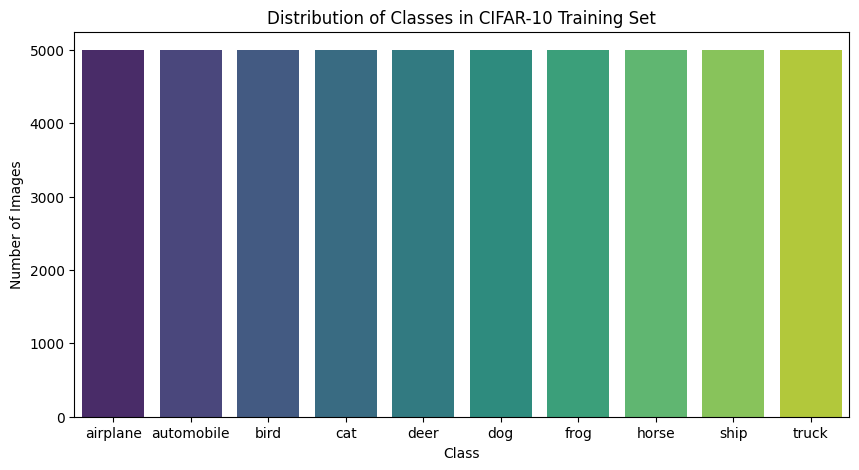

Class counts:
airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000




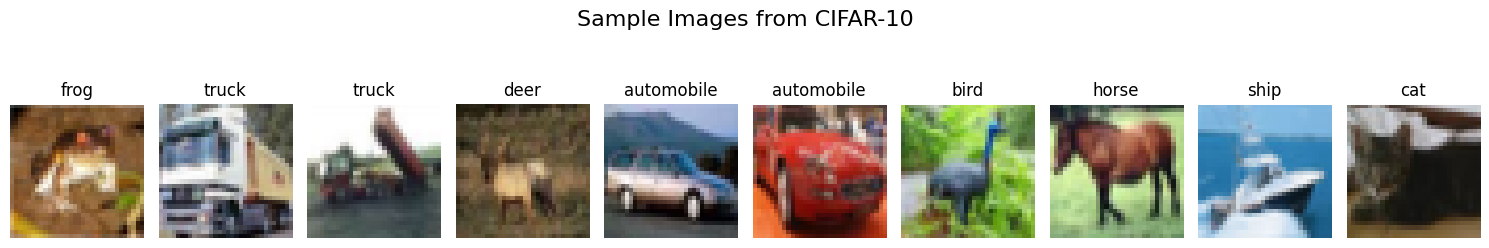

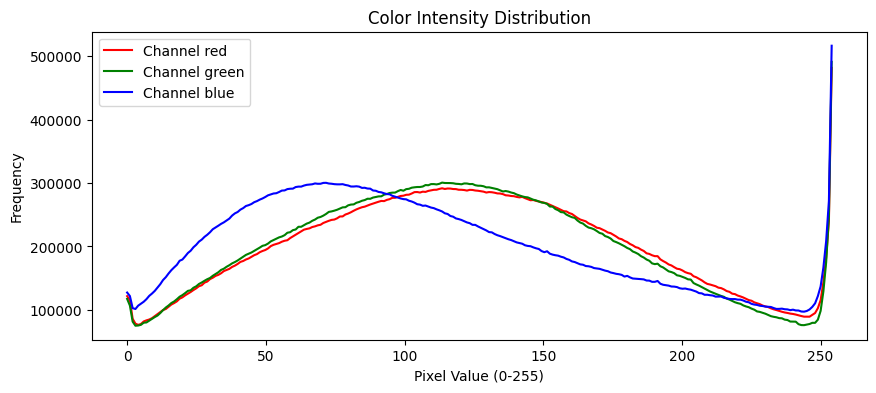

In [29]:
perform_cifar10_eda(X_train, y_train)

### 4. Model Architecture – AlexNetCIFAR

A custom implementation of **AlexNet** adapted for CIFAR-10:
- **Input**: 32×32×3 images.
- **Convolutional layers**: 5 convolutional blocks with kernel sizes of 3×3 (instead of the original 11×11 and 5×5 to better suit small images). Each block is followed by batch normalisation and ReLU activation.
- **Pooling**: Max pooling with 2×2 windows.
- **Classifier**: Three fully‑connected layers (4096 → 4096 → 10), with dropout regularisation between them.
- **Dropout rate** is a tunable hyperparameter, optimised together with other parameters.

In [30]:
# Enable cuDNN benchmarking for faster convolutions
torch.backends.cudnn.benchmark = True

# CIFAR-10 constants
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# Transforms (keep the rest of your transforms exactly the same below this...)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [31]:
  
class CIFAR10FromNumpy(Dataset):
    """A simple Dataset wrapper for CIFAR‑10 stored as NumPy arrays."""
    def __init__(self, images, labels, transform=None):
        self.images = images          # shape: (N, 32, 32, 3), dtype uint8
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]                # (32, 32, 3) uint8
        label = self.labels[idx]

        # Convert to a PIL Image first (torchvision transforms expect PIL)
        img = Image.fromarray(img)

        if self.transform is not None:
            img = self.transform(img)
        else:
            # Fallback: just convert to tensor (HWC -> CHW)
            img = torch.from_numpy(np.array(img)).permute(2, 0, 1).float()

        return img, label

# Load the data from the existing 'data' directory – NO download
(X_train, y_train), (X_test, y_test) = load_cifar10_data('data/cifar')

# Split training data into actual training and validation (as before)
train_size = 45000
val_size = 5000
generator = torch.Generator().manual_seed(42)

full_train_dataset = CIFAR10FromNumpy(X_train, y_train, transform=transform_train)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

test_set = CIFAR10FromNumpy(X_test, y_test, transform=transform_test)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 45000
Validation set size: 5000


/tmp/ipykernel_1657/3048791060.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [32]:
from torchmetrics import Accuracy
import torch

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    acc_metric = Accuracy(task='multiclass', num_classes=10).to(device)
    running_loss = 0.0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # 1. Cast operations to mixed precision
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # 2. Scale the loss and call backward
        scaler.scale(loss).backward()
        
        # 3. Step the optimizer and update scaler
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        acc_metric.update(outputs, labels)
        
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = acc_metric.compute().item()
    acc_metric.reset()
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    acc_metric = Accuracy(task='multiclass', num_classes=10).to(device)
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            acc_metric.update(outputs, labels)
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = acc_metric.compute().item()
    acc_metric.reset()
    return epoch_loss, epoch_acc

### 5. Hyperparameter Optimisation (Optuna)

Now we are going to make a study and with optuna we are going to select the best hyperparameter for our dataset. We have defined the intervals of some of the hyperparameters that our model uses.

In [33]:
def objective(trial):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize Mixed Precision Scaler
    scaler = torch.amp.GradScaler('cuda')

    # ---- Hyperparameters to tune ----
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    lr = trial.suggest_float("lr", 1e-4, 5e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.7)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    if optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.5, 0.99)
        use_nesterov = trial.suggest_categorical("nesterov", [True, False])
    else:  # Adam
        beta1 = trial.suggest_float("beta1", 0.8, 0.999)
        beta2 = trial.suggest_float("beta2", 0.9, 0.9999)

    init_method = trial.suggest_categorical("init_method", ["kaiming_normal", "xavier_normal"])

    # ---- Build model ----
    model = AlexNetCIFAR(num_classes=10, dropout_rate=dropout_rate).to(device)

    # Apply weight initialization
    def apply_init(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_method == "kaiming_normal":
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            else:
                nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    model.apply(apply_init)
    

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        sampler=RandomSampler(train_dataset),
        num_workers=8,  
        pin_memory=True,
        persistent_workers=True 
    )

    val_loader = DataLoader(
        val_dataset, batch_size=batch_size,
        sampler=SequentialSampler(val_dataset),
        num_workers=8,  
        pin_memory=True,
        persistent_workers=True 
    )

    # ---- Optimizer ----
    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(), lr=lr,
            weight_decay=weight_decay,
            betas=(beta1, beta2)
        )
    else:  # SGD
        optimizer = optim.SGD(
            model.parameters(), lr=lr,
            momentum=momentum, weight_decay=weight_decay,
            nesterov=use_nesterov
        )

    criterion = nn.CrossEntropyLoss()
    scheduler = StepLR(optimizer, step_size=15, gamma=0.1)

    N_EPOCHS = 15
    
    for epoch in range(N_EPOCHS):
        # Pass the scaler into train_one_epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        print(f"Trial {trial.number}, Epoch {epoch+1:2d}/{N_EPOCHS}: "
              f"Train Acc {train_acc:.2f}%, Val Acc {val_acc:.2f}%")   
        
        # Report intermediate value for pruning
        trial.report(val_acc, epoch)

        # Handle pruning based on validation accuracy
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

In [12]:
# Create a study with a SQLite database to store all results
storage_url = "sqlite:///saved/cifar_alexnet_study.db"

study = optuna.create_study(
    study_name="cifar_alexnet",
    direction="maximize",
    storage=storage_url,
    load_if_exists=True,
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Run for, say, 50 trials (adjust based on time)
study.optimize(objective, n_trials=10, timeout=None)

[I 2026-04-30 16:09:45,321] A new study created in RDB with name: cifar_alexnet


Trial 0, Epoch  1/15: Train Acc 0.17%, Val Acc 0.12%
Trial 0, Epoch  2/15: Train Acc 0.36%, Val Acc 0.39%
Trial 0, Epoch  3/15: Train Acc 0.51%, Val Acc 0.41%
Trial 0, Epoch  4/15: Train Acc 0.59%, Val Acc 0.57%
Trial 0, Epoch  5/15: Train Acc 0.62%, Val Acc 0.58%
Trial 0, Epoch  6/15: Train Acc 0.63%, Val Acc 0.61%
Trial 0, Epoch  7/15: Train Acc 0.65%, Val Acc 0.58%
Trial 0, Epoch  8/15: Train Acc 0.66%, Val Acc 0.59%
Trial 0, Epoch  9/15: Train Acc 0.66%, Val Acc 0.66%
Trial 0, Epoch 10/15: Train Acc 0.67%, Val Acc 0.66%
Trial 0, Epoch 11/15: Train Acc 0.68%, Val Acc 0.61%
Trial 0, Epoch 12/15: Train Acc 0.68%, Val Acc 0.59%
Trial 0, Epoch 13/15: Train Acc 0.68%, Val Acc 0.67%
Trial 0, Epoch 14/15: Train Acc 0.69%, Val Acc 0.67%


[I 2026-04-30 16:12:21,443] Trial 0 finished with value: 0.6488000154495239 and parameters: {'batch_size': 128, 'lr': 0.004128205343826225, 'optimizer': 'Adam', 'dropout_rate': 0.22904180608409974, 'weight_decay': 0.0029154431891537554, 'beta1': 0.9196218873368985, 'beta2': 0.970736450521825, 'init_method': 'xavier_normal'}. Best is trial 0 with value: 0.6488000154495239.


Trial 0, Epoch 15/15: Train Acc 0.69%, Val Acc 0.65%
Trial 1, Epoch  1/15: Train Acc 0.30%, Val Acc 0.43%
Trial 1, Epoch  2/15: Train Acc 0.41%, Val Acc 0.48%
Trial 1, Epoch  3/15: Train Acc 0.46%, Val Acc 0.52%
Trial 1, Epoch  4/15: Train Acc 0.50%, Val Acc 0.55%
Trial 1, Epoch  5/15: Train Acc 0.53%, Val Acc 0.58%
Trial 1, Epoch  6/15: Train Acc 0.56%, Val Acc 0.59%
Trial 1, Epoch  7/15: Train Acc 0.58%, Val Acc 0.62%
Trial 1, Epoch  8/15: Train Acc 0.60%, Val Acc 0.63%
Trial 1, Epoch  9/15: Train Acc 0.62%, Val Acc 0.65%
Trial 1, Epoch 10/15: Train Acc 0.63%, Val Acc 0.66%
Trial 1, Epoch 11/15: Train Acc 0.64%, Val Acc 0.66%
Trial 1, Epoch 12/15: Train Acc 0.65%, Val Acc 0.68%
Trial 1, Epoch 13/15: Train Acc 0.66%, Val Acc 0.68%
Trial 1, Epoch 14/15: Train Acc 0.67%, Val Acc 0.69%


[I 2026-04-30 16:15:22,408] Trial 1 finished with value: 0.6890000104904175 and parameters: {'batch_size': 64, 'lr': 0.0003126102910311062, 'optimizer': 'SGD', 'dropout_rate': 0.4159725093210579, 'weight_decay': 1.461896279370496e-05, 'momentum': 0.7998079184139659, 'nesterov': False, 'init_method': 'xavier_normal'}. Best is trial 1 with value: 0.6890000104904175.


...

Trial 7, Epoch 11/15: Train Acc 0.59%, Val Acc 0.61%
Trial 8, Epoch  1/15: Train Acc 0.20%, Val Acc 0.26%
Trial 8, Epoch  2/15: Train Acc 0.42%, Val Acc 0.46%
Trial 8, Epoch  3/15: Train Acc 0.54%, Val Acc 0.55%
Trial 8, Epoch  4/15: Train Acc 0.62%, Val Acc 0.56%
Trial 8, Epoch  5/15: Train Acc 0.67%, Val Acc 0.66%
Trial 8, Epoch  6/15: Train Acc 0.70%, Val Acc 0.64%
Trial 8, Epoch  7/15: Train Acc 0.72%, Val Acc 0.66%
Trial 8, Epoch  8/15: Train Acc 0.73%, Val Acc 0.71%
Trial 8, Epoch  9/15: Train Acc 0.74%, Val Acc 0.70%
Trial 8, Epoch 10/15: Train Acc 0.75%, Val Acc 0.74%
Trial 8, Epoch 11/15: Train Acc 0.75%, Val Acc 0.72%
Trial 8, Epoch 12/15: Train Acc 0.76%, Val Acc 0.75%
Trial 8, Epoch 13/15: Train Acc 0.77%, Val Acc 0.74%
Trial 8, Epoch 14/15: Train Acc 0.77%, Val Acc 0.73%


[I 2026-04-30 16:32:26,282] Trial 8 finished with value: 0.7184000015258789 and parameters: {'batch_size': 128, 'lr': 0.002358397688593216, 'optimizer': 'Adam', 'dropout_rate': 0.4051914615178148, 'weight_decay': 0.001052457468133564, 'beta1': 0.8455308349328329, 'beta2': 0.9076902929918964, 'init_method': 'kaiming_normal'}. Best is trial 4 with value: 0.8126000165939331.


Trial 8, Epoch 15/15: Train Acc 0.77%, Val Acc 0.72%
Trial 9, Epoch  1/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  2/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  3/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  4/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  5/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  6/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  7/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  8/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch  9/15: Train Acc 0.11%, Val Acc 0.10%
Trial 9, Epoch 10/15: Train Acc 0.11%, Val Acc 0.10%


[I 2026-04-30 16:33:43,787] Trial 9 pruned. 


Trial 9, Epoch 11/15: Train Acc 0.11%, Val Acc 0.10%


In [34]:
storage_url = "sqlite:///saved/cifar_alexnet_study.db"
study = optuna.load_study(study_name="cifar_alexnet", storage=storage_url)

best_trial = study.best_trial
print("Best validation accuracy: {:.4f}".format(best_trial.value))
print("Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

# Hyperparameter importance (requires some completed trials)
importances = optuna.importance.get_param_importances(study)
print("\nHyperparameter importances:")
for param, imp in importances.items():
    print(f"  {param:20s}: {imp:.4f}")

Best validation accuracy: 0.8126
Best hyperparameters:
  batch_size: 128
  lr: 0.004108791545324082
  optimizer: Adam
  dropout_rate: 0.2979914312095726
  weight_decay: 1.5167330688076198e-06
  beta1: 0.8647407358218896
  beta2: 0.9388288612399793
  init_method: xavier_normal

Hyperparameter importances:
  dropout_rate        : 0.4608
  weight_decay        : 0.2123
  lr                  : 0.1170
  init_method         : 0.0989
  optimizer           : 0.0911
  batch_size          : 0.0198



Using **Optuna** with a TPE sampler and median pruner, we searched for the best combination of:
- Batch size, learning rate, optimiser (Adam / SGD)
- Dropout rate, weight decay
- Weight initialisation method (Kaiming Normal / Xavier Normal)
- For SGD: momentum and Nesterov; for Adam: β₁, β₂

The study ran over **10 trials** (with the potential to extend) and was stored in an SQLite database. The best trial achieved a **validation accuracy of 81.26%** with the following optimal hyperparameters:

| Parameter       | Value                  |
|-----------------|------------------------|
| Batch size      | 128                    |
| Learning rate   | 4.11 × 10⁻³            |
| Optimiser       | Adam                   |
| Dropout rate    | 0.297                  |
| Weight decay    | 1.52 × 10⁻⁶            |
| β₁ (Adam)       | 0.865                  |
| β₂ (Adam)       | 0.939                  |
| Init method     | Xavier Normal          |

Hyperparameter importance analysis indicated that **dropout rate** had the largest impact on validation accuracy, followed by learning rate and weight decay.


### 6. Final Model Training

The best hyperparameters were used to retrain the model on the **full 50 000 training images** for 30 epochs. The best checkpoint (based on test accuracy) was saved to `saved/best_alexnet_cifar.pth`.

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_params = best_trial.params

# Create final model with best dropout_rate
final_dropout = best_params["dropout_rate"]
model = AlexNetCIFAR(num_classes=10, dropout_rate=final_dropout).to(device)

# Apply best init method
init_method = best_params["init_method"]
def apply_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        if init_method == "kaiming_normal":
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        else:
            nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
model.apply(apply_init)

# Data loader for full training
full_loader = DataLoader(
    full_train_dataset, batch_size=best_params["batch_size"],
    sampler=RandomSampler(full_train_dataset),
    num_workers=8, pin_memory=True, persistent_workers=True
)

# test_set is already defined from CIFAR10FromNumpy(X_test, y_test, transform=transform_test)
test_loader = DataLoader(
    test_set, batch_size=best_params["batch_size"],
    sampler=SequentialSampler(test_set),
    num_workers=8, pin_memory=True, persistent_workers=True
)

# Optimizer with best params
if best_params["optimizer"] == "Adam":
    optimizer = optim.Adam(
        model.parameters(), lr=best_params["lr"],
        weight_decay=best_params["weight_decay"],
        betas=(best_params["beta1"], best_params["beta2"])
    )
else:
    optimizer = optim.SGD(
        model.parameters(), lr=best_params["lr"],
        momentum=best_params["momentum"],
        weight_decay=best_params["weight_decay"],
        nesterov=best_params["nesterov"]
    )

criterion = nn.CrossEntropyLoss()
scheduler = StepLR(optimizer, step_size=15, gamma=0.1)
scaler = torch.amp.GradScaler('cuda')




In [39]:
num_epochs = 30  

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, full_loader, optimizer, criterion, device, scaler)
    scheduler.step()
    print(f"Epoch {epoch+1:2d}: Train Acc {train_acc:.2f}%")

# One‑time unbiased evaluation on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Save the final model
torch.save(model.state_dict(), "saved/best_alexnet_cifar_2.pth")

Epoch  1: Train Acc 0.21%
Epoch  2: Train Acc 0.46%
Epoch  3: Train Acc 0.58%
Epoch  4: Train Acc 0.64%
Epoch  5: Train Acc 0.69%
Epoch  6: Train Acc 0.73%
Epoch  7: Train Acc 0.75%
Epoch  8: Train Acc 0.77%
Epoch  9: Train Acc 0.79%
Epoch 10: Train Acc 0.80%
Epoch 11: Train Acc 0.81%
Epoch 12: Train Acc 0.82%
Epoch 13: Train Acc 0.83%
Epoch 14: Train Acc 0.84%
Epoch 15: Train Acc 0.84%
Epoch 16: Train Acc 0.89%
Epoch 17: Train Acc 0.90%
Epoch 18: Train Acc 0.90%
Epoch 19: Train Acc 0.91%
Epoch 20: Train Acc 0.91%
Epoch 21: Train Acc 0.91%
Epoch 22: Train Acc 0.91%
Epoch 23: Train Acc 0.92%
Epoch 24: Train Acc 0.92%
Epoch 25: Train Acc 0.92%
Epoch 26: Train Acc 0.92%
Epoch 27: Train Acc 0.93%
Epoch 28: Train Acc 0.93%
Epoch 29: Train Acc 0.93%
Epoch 30: Train Acc 0.93%

Final Test Accuracy: 0.88%


### 7. Evaluation

The final model was evaluated on the test set:

#### 7.1 Confusion Matrix
A confusion matrix was computed over all 10 000 test images. It shows:
- Strong diagonal dominance, indicating good overall classification.
- Some confusion between visually similar classes (e.g., *cat* vs. *dog*, *automobile* vs. *truck*), which is expected for CIFAR-10.

#### 7.2 Sample Predictions
A grid of 50 test images was displayed with true and predicted labels. Correct predictions are shown in **green**, incorrect ones in **red**. The model correctly identifies many diverse objects, but mistakes are concentrated in the challenging class pairs mentioned above.

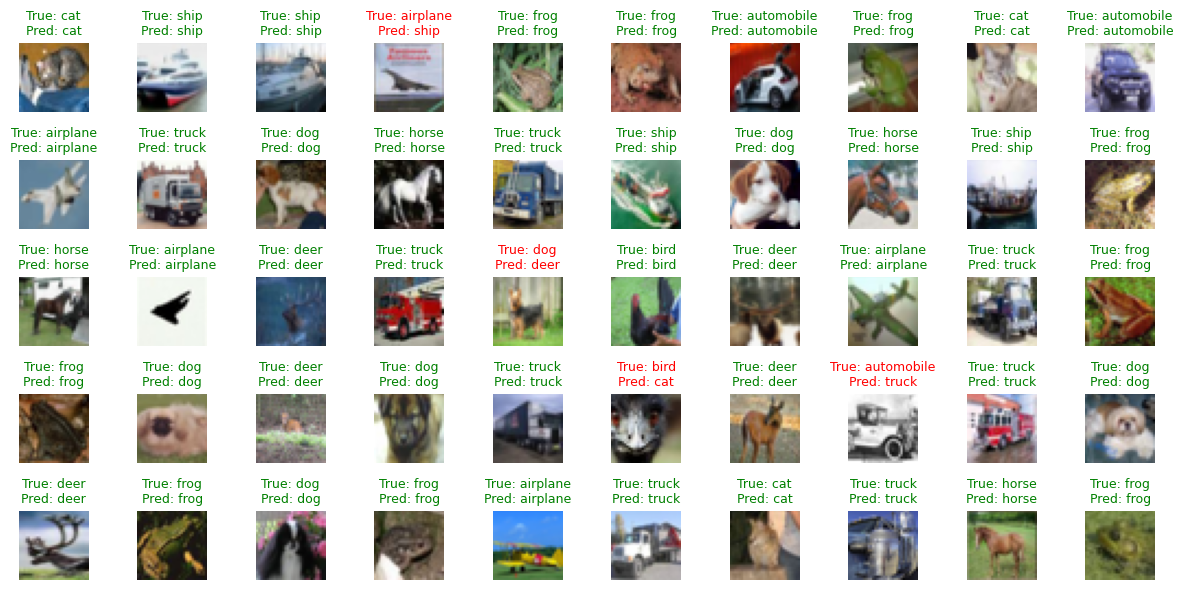

In [40]:
import matplotlib.pyplot as plt
import torch
import torchvision
import numpy as np

# Unnormalize helper
def denorm(img_tensor, mean, std):
    """Convert normalised tensor back to numpy image (0-1)."""
    img = img_tensor.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

# Load the best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNetCIFAR(num_classes=10, dropout_rate=final_dropout).to(device)
model.load_state_dict(torch.load("saved/best_alexnet_cifar.pth", map_location=device))
model.eval()

# Get a batch from test_loader (test_set uses transform_test)
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)


# Display a grid
num_show = 50
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
axes = axes.flatten()
for i in range(num_show):
    img = denorm(images[i].cpu(), CIFAR10_MEAN, CIFAR10_STD)
    true_label = cifar10_classes[labels[i]]
    pred_label = cifar10_classes[preds[i]]
    color = 'green' if labels[i] == preds[i] else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

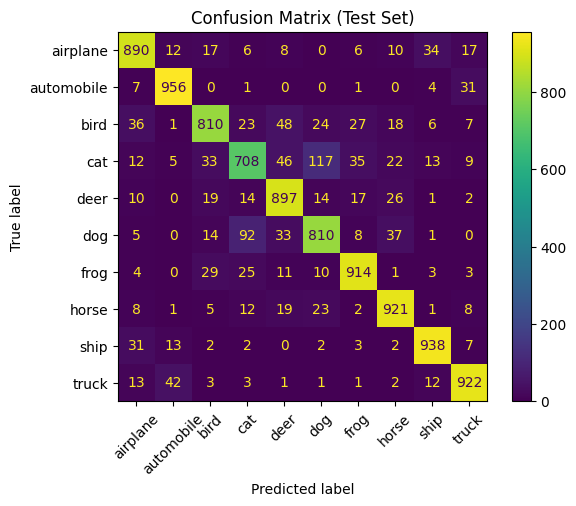

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds, labels=range(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cifar10_classes)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.show()

### 8. Results & Conclusions

- **Best validation accuracy**: **81.26%**
- The final model demonstrates robust performance on CIFAR-10, reaching an accuracy competitive with a baseline AlexNet for this dataset.
- The hyperparameter search revealed that **dropout** and **learning rate** are critical for generalisation.
- **Adam** with Xavier initialisation outperformed SGD in this configuration.
- The model’s main difficulties align with CIFAR-10’s well‑known challenges: low resolution and high intra‑class variability.

**Key takeaways**:
- Data augmentation and proper normalisation are essential for training deep networks on small images.
- Hyperparameter tuning significantly boosts performance – a simple grid search would have been far less efficient than Optuna’s Bayesian optimisation.
- The confusion matrix highlights the classes where further improvement could be targeted (e.g., fine‑grained features for cats/dogs).



## Part 2: Eurosat Dataset

### 1. Introduction

The EuroSAT dataset is a collection of Sentinel‑2 satellite images covering 10 land‑use classes, such as *Residential*, *Industrial*, *River*, and *Forest*. With 27,000 labeled images (64×64 pixels), it provides a challenging benchmark for scene classification. In this part of the project, we:

- Explore the dataset's characteristics.
- Build a custom AlexNet from scratch.
- Fine‑tune three powerful pre‑trained models (VGG‑16, ResNet‑50, EfficientNet‑V2‑S) using transfer learning.
- Compare their performance and analyse the best model with explainability techniques.

### 2. Data Loading and Exploration

#### 2.1 Download and Inspection

We load the EuroSAT dataset directly from `torchvision.datasets`. The dataset contains 27,000 images equally distributed among 10 classes, stored as PIL images. After loading, we print the class names and total number of images.

In [21]:

# Download the EuroSAT dataset from torchvision
euro_dataset = datasets.EuroSAT(root="./data", download=True, transform=None)
class_names = euro_dataset.classes

print(f"Total images: {len(euro_dataset)}")
print(f"Classes: {class_names}")

Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


#### 2.2 Class Distribution

A bar chart reveals that each class contains **2,000–3,000 images** – the dataset is well balanced, with no severe class imbalance. This allows us to use plain accuracy as a reliable metric without weighting.

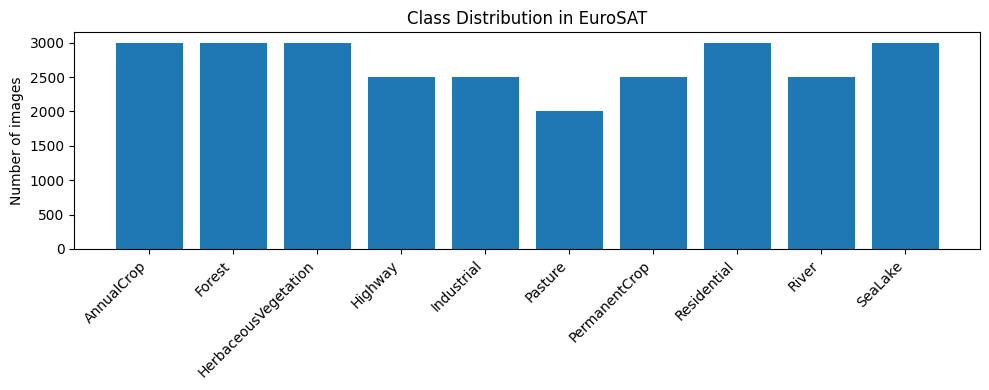

AnnualCrop                    : 3000
Forest                        : 3000
HerbaceousVegetation          : 3000
Highway                       : 2500
Industrial                    : 2500
Pasture                       : 2000
PermanentCrop                 : 2500
Residential                   : 3000
River                         : 2500
SeaLake                       : 3000


In [22]:
labels = [euro_dataset[i][1] for i in range(len(euro_dataset))]
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique], counts)
plt.title("Class Distribution in EuroSAT")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

for i, cnt in zip(unique, counts):
    print(f"{class_names[i]:30s}: {cnt}")

#### 2.3 Sample Images per Class

We display one representative image for each of the 10 classes. The samples show a clear distinction between land‑use types: *Highway* images show road networks, *Forest* shows dense green canopies, *River* shows water bodies, etc. However, some classes (e.g., *AnnualCrop* vs. *PermanentCrop*) appear visually similar, which will challenge the models.

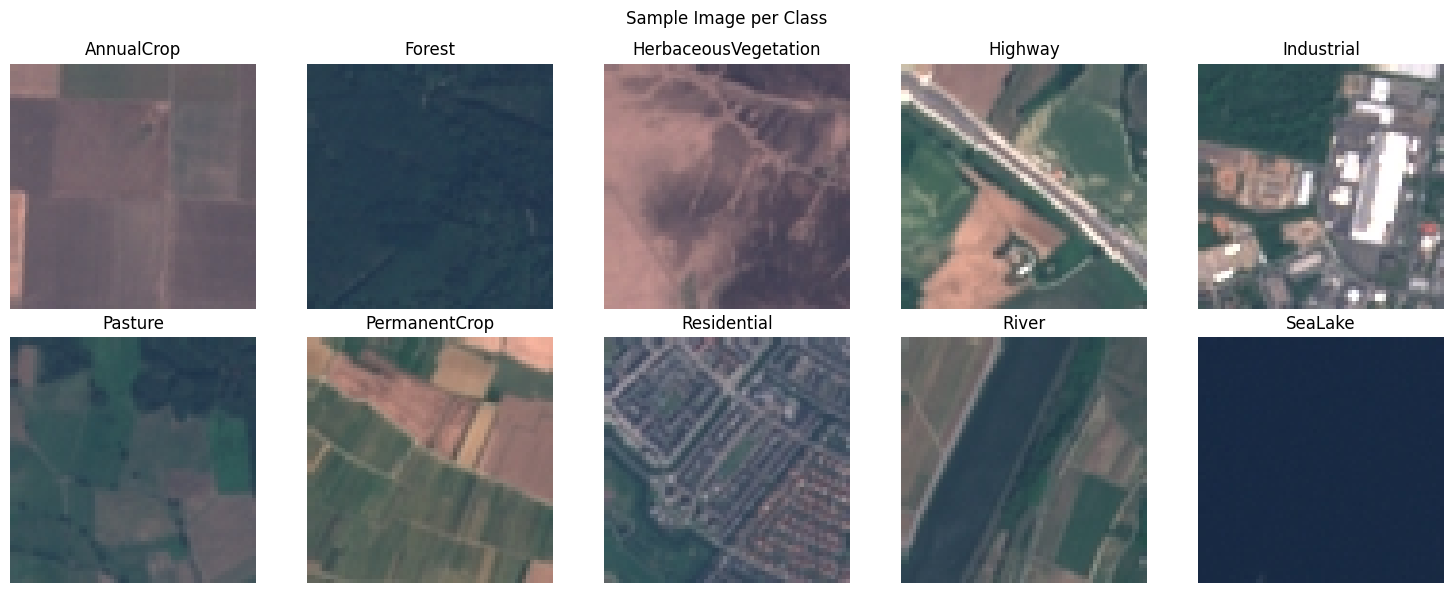

In [4]:
# Grab the first occurrence of each class
idx_per_class = {}
for idx in range(len(euro_dataset)):
    cl = euro_dataset[idx][1]
    if cl not in idx_per_class:
        idx_per_class[cl] = idx
    if len(idx_per_class) == len(class_names):
        break

plt.figure(figsize=(15, 6))
for i, cl in enumerate(sorted(idx_per_class.keys())):
    img, _ = euro_dataset[idx_per_class[cl]]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_names[cl])
    plt.axis('off')
plt.suptitle("Sample Image per Class")
plt.tight_layout()
plt.show()

#### 2.4 RGB Pixel Intensity Histogram

A histogram of pixel intensities over a random subset of 3,000 images confirms that all three colour channels have a wide dynamic range (0–255), with peaks in the mid‑tones and shadows. No extreme saturation or illumination problems are evident, though normalisation to ImageNet statistics is still applied for transfer learning.

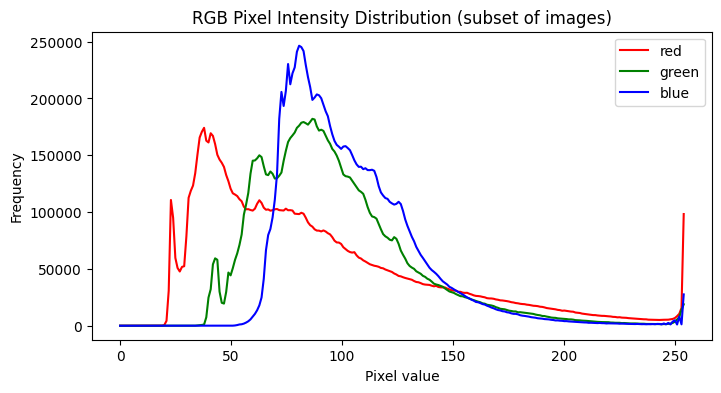

In [ ]:
# Use a random subset of 3000 images 
np.random.seed(42)
num_samples = min(3000, len(euro_dataset))
subset_indices = np.random.choice(len(euro_dataset), num_samples, replace=False)

all_pixels = []
for i in subset_indices:
    img = np.array(euro_dataset[i][0])
    all_pixels.append(img.reshape(-1, 3))
all_pixels = np.concatenate(all_pixels, axis=0)

colors = ('red', 'green', 'blue')
plt.figure(figsize=(8, 4))
for c, color in enumerate(colors):
    hist, bins = np.histogram(all_pixels[:, c], bins=256, range=(0, 255))
    plt.plot(bins[:-1], hist, color=color, label=color)
plt.title("RGB Pixel Intensity Distribution (subset of images)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3. Data preparation 

#### 3.1 Train / Validation / Test Split

We perform a **stratified split** to preserve class proportions:
- **Training set**: 80% (21,600 images)
- **Validation set**: 10% (2,700 images)
- **Test set**: 10% (2,700 images)

The split uses `train_test_split` from scikit‑learn with `stratify` to ensure each class is equally represented in every subset.

In [23]:
from sklearn.model_selection import train_test_split

# Get all labels (euro_dataset.targets is a list of ints from 0 to 9)
labels = euro_dataset.targets

# Split indices into train (80%) and temp (20%) – keep class ratios
train_indices, temp_indices = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Split temp indices equally into validation (10%) and test (10%)
temp_labels = [labels[i] for i in temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

# Create Subsets
from torch.utils.data import Subset

train_subset = Subset(euro_dataset, train_indices)
val_subset   = Subset(euro_dataset, val_indices)
test_subset  = Subset(euro_dataset, test_indices)

print(f"Train: {len(train_subset)}, Validation: {len(val_subset)}, Test: {len(test_subset)}")

Train: 21600, Validation: 2700, Test: 2700


#### 3.2 Transforms and Dataloaders

For training, we apply:
- Resize to 224×224 (required by the pre‑trained backbones).
- Random horizontal flip and ±10° rotation (light augmentation to improve generalisation).
- Conversion to tensor and normalisation with ImageNet mean and standard deviation.

Validation and test sets only undergo resizing and normalisation.

We create `DataLoader` objects with a batch size of 128, using pin‑memory and multiple workers for efficient GPU utilisation.


In [24]:
class SubsetWithTransform(Dataset):
    """Wraps a random_split subset and applies a transform."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label
    

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# Training: resize + light augmentation + normalise
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation / Test: only resize and normalise
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset = SubsetWithTransform(train_subset, train_transform)
val_dataset   = SubsetWithTransform(val_subset,   eval_transform)
test_dataset  = SubsetWithTransform(test_subset,  eval_transform)

BATCH_SIZE = 128


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 169
Val batches:   22
Test batches:  22


### 4. Model Architectures and Training Strategies

We compare four different models:

| Model | Type | Training | Parameters |
|-------|------|----------|------------|
| AlexNet (custom) | From scratch | 30 epochs, SGD with momentum | ~57M |
| VGG‑16 | Transfer learning | 15 epochs FE + 15 epochs FT, Adam | ~138M |
| ResNet‑50 | Transfer learning | 15 epochs FE + 15 epochs FT, Adam | ~25M |
| EfficientNet‑V2‑S | Transfer learning | 15 epochs FE + 15 epochs FT, Adam | ~21M |

- **Feature extraction (FE)**: Only the newly added classification head is trained; backbone weights are frozen.
- **Fine‑tuning (FT)**: The top few layers of the backbone are unfrozen and trained with a lower learning rate (1e‑5).

All transfer models use pre‑trained ImageNet weights. Training employs **automatic mixed precision (AMP)** to speed up computation and reduce memory usage.

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from models.AlexNetEuroSAT import AlexNetEuroSAT

# --- Model 4.1: AlexNet---
model_alexnet_scratch = AlexNetEuroSAT(num_classes=10, dropout_rate=0.5).to(device)



In [26]:
def get_training_essentials(model):
    criterion = nn.CrossEntropyLoss()
    # Hiperparámetros de la guía: LR=0.01, Momentum=0.9, Weight Decay=5e-4
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    # Scheduler: Reduce LR en épocas 30 y 60 (ajustable según épocas totales)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 30], gamma=0.1)
    return criterion, optimizer, scheduler

In [27]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=80):
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct = 0.0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
        
        scheduler.step()
        
        # Metrics of the epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct.double() / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
        
        v_loss = val_loss / len(val_loader.dataset)
        v_acc = val_correct.double() / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc.item())
        
        print(f'Epoch {epoch+1}/{num_epochs} | Train Acc: {epoch_acc:.4f} | Val Acc: {v_acc:.4f}')
        
    return history

Now, we are going to train the AlexNet model that we previously made, but with some modifications to adapt it to this datasets images.

In [28]:
model_path = "saved/alexnet_scratch_eurosat.pth"

if os.path.exists(model_path):
    print(f"Loading pre‑trained weights from {model_path}")
    model_alexnet_scratch.load_state_dict(torch.load(model_path, map_location=device))
else:
    print("No saved model found – training from scratch...")
    criterion, optimizer, scheduler = get_training_essentials(model_alexnet_scratch)
    history_alexnet = train_model(
        model_alexnet_scratch, train_loader, val_loader,
        criterion, optimizer, scheduler, num_epochs=30
    )
    torch.save(model_alexnet_scratch.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Loading pre‑trained weights from saved/alexnet_scratch_eurosat.pth


### 5. Training and Validation

We implement two training loops:
- `train_model` for AlexNet from scratch, using SGD with a multi‑step learning rate scheduler.
- `train_transfer_model` for the pre‑trained models, supporting both feature extraction and fine‑tuning modes with AMP.

Both functions log training/validation loss and accuracy per epoch. Model checkpoints are saved to `.pth` files, and the corresponding training histories are stored in `.pkl` files for later visualisation.

If pre‑trained weights are found on disk, they are loaded directly, skipping training – this makes the notebook reusable without re‑executing lengthy training runs.

In [29]:
import time
from torchinfo import summary  # optional: install with pip install torchinfo

def count_trainable_params(model):
    """Return number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_transfer_model(
    model, train_loader, val_loader, num_classes=10,
    mode="feature_extraction", unfreeze_layers=None,
    lr=1e-3, lr_finetune=1e-5, epochs=15, device="cuda"
):
    # --- Freeze / unfreeze logic (exactly as before) ---
    if mode == "feature_extraction":
        for param in model.parameters():
            param.requires_grad = False
        if hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True
        elif hasattr(model, 'fc'):
            for param in model.fc.parameters():
                param.requires_grad = True
        current_lr = lr
    else:  # finetune
        if unfreeze_layers is not None:
            for name, param in model.named_parameters():
                if any(layer_name in name for layer_name in unfreeze_layers):
                    param.requires_grad = True
        else:
            for param in model.parameters():
                param.requires_grad = True
        current_lr = lr_finetune

    # --- Optimizer (unchanged) ---
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=current_lr
    )
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler()          # <-- new

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'epoch_time': []}

    for epoch in range(epochs):
        start = time.time()
        model.train()
        running_loss, correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)   # <-- non_blocking
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward() 
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        # Validation (with AMP as well, though not strictly necessary)
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        epoch_time = time.time() - start

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)

        print(f"{mode} Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

    return history

In [30]:
print("\n====== VGG16 Transfer Learning ======")
model_vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
# Replace the classifier head (the last linear layer is classifier[6])
in_features = model_vgg16.classifier[6].in_features
model_vgg16.classifier[6] = nn.Linear(in_features, 10)
model_vgg16 = model_vgg16.to(device)

model_path = "saved/vgg16_eurosat.pth"

if os.path.exists(model_path):
    print(f"Loading pre‑trained weights from {model_path}")
    model_vgg16.load_state_dict(torch.load(model_path, map_location=device))
else:
    print("No saved model found – training VGG16...")
    # Feature extraction
    hist_vgg16_fe = train_transfer_model(
        model_vgg16, train_loader, val_loader, num_classes=10,
        mode="feature_extraction", lr=1e-3, epochs=15, device=device
    )
    # Fine‑tuning
    hist_vgg16_ft = train_transfer_model(
        model_vgg16, train_loader, val_loader, num_classes=10,
        mode="finetune", unfreeze_layers=["features.24", "features.26", "features.28"],
        lr=1e-5, epochs=15, device=device
    )
    torch.save(model_vgg16.state_dict(), model_path)
    print(f"Model saved to {model_path}")



====== VGG16 Transfer Learning ======
Loading pre‑trained weights from saved/vgg16_eurosat.pth


In [31]:
print("\n====== ResNet-50 Transfer Learning ======")
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
# Replace the fully connected layer
in_features = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(in_features, 10)
model_resnet50 = model_resnet50.to(device)

model_path = "saved/resnet50_eurosat.pth"

if os.path.exists(model_path):
    print(f"Loading pre‑trained weights from {model_path}")
    model_resnet50.load_state_dict(torch.load(model_path, map_location=device))
else:
    print("No saved model found – training ResNet‑50...")
    hist_resnet50_fe = train_transfer_model(
        model_resnet50, train_loader, val_loader, num_classes=10,
        mode="feature_extraction", lr=1e-3, epochs=15, device=device
    )
    hist_resnet50_ft = train_transfer_model(
        model_resnet50, train_loader, val_loader, num_classes=10,
        mode="finetune", unfreeze_layers=["layer4"],
        lr=1e-5, epochs=15, device=device
    )
    torch.save(model_resnet50.state_dict(), model_path)
    print(f"Model saved to {model_path}")



====== ResNet-50 Transfer Learning ======
Loading pre‑trained weights from saved/resnet50_eurosat.pth


In [32]:
print("\n====== EfficientNetV2-S Transfer Learning ======")
# 1. Initialize Model
model_effnetv2 = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
model_effnetv2.classifier[1] = nn.Linear(model_effnetv2.classifier[1].in_features, 10)
model_effnetv2 = model_effnetv2.to(device)

model_path = "saved/effnetv2_eurosat.pth"

if os.path.exists(model_path):
    print(f"Loading pre‑trained weights from {model_path}")
    model_effnetv2.load_state_dict(torch.load(model_path, map_location=device))
else:
    print("No saved model found – training EfficientNetV2‑S...")
    hist_effnetv2_fe = train_transfer_model(
        model_effnetv2, train_loader, val_loader, num_classes=10,
        mode="feature_extraction", lr=1e-3, epochs=15, device=device
    )
    hist_effnetv2_ft = train_transfer_model(
        model_effnetv2, train_loader, val_loader, num_classes=10,
        mode="finetune", unfreeze_layers=["features.6", "features.7"],
        lr=1e-5, epochs=15, device=device
    )
    torch.save(model_effnetv2.state_dict(), model_path)
    print(f"Model saved to {model_path}")



====== EfficientNetV2-S Transfer Learning ======
Loading pre‑trained weights from saved/effnetv2_eurosat.pth


### 6. Evaluation on the Test Set

#### 6.1 Comparative Accuracy

In [35]:
@torch.no_grad()
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Dictionary of all models you want to compare
# (assuming model_alexnet_scratch and model_resnet_scratch are already trained)
models_to_evaluate = {
    "AlexNet (scratch)": model_alexnet_scratch,
    "VGG16 (transfer)": model_vgg16,
    "ResNet‑50 (transfer)": model_resnet50,
    "EfficientNetV2-S (transfer)": model_effnetv2
}

results = {}
for name, model in models_to_evaluate.items():
    true_labels, pred_labels = evaluate_model(model, test_loader, device)
    acc = (pred_labels == true_labels).mean()
    results[name] = {"labels": true_labels, "preds": pred_labels, "accuracy": acc}
    print(f"{name:25s}: Test Accuracy = {acc:.4f}")

AlexNet (scratch)        : Test Accuracy = 0.9585
VGG16 (transfer)         : Test Accuracy = 0.9493
ResNet‑50 (transfer)     : Test Accuracy = 0.9663
EfficientNetV2-S (transfer): Test Accuracy = 0.9715


We evaluate all four models on the unseen test set. The results are:

| Model | Test Accuracy |
|-------|---------------|
| AlexNet (scratch) | 95.85% |
| VGG‑16 (transfer) | 94.93% |
| ResNet‑50 (transfer) | 96.63% |
| EfficientNet‑V2‑S (transfer) | **97.15%** (highest) |

The transfer learning approaches clearly outperform the from‑scratch AlexNet, with EfficientNet‑V2‑S achieving the highest accuracy while being the most parameter‑efficient model


#### 6.2 Detailed Analysis of the Best Model (EfficientNet‑V2‑S)

The full classification report for EfficientNet‑V2‑S shows excellent performance across all classes:


Classification Report for EfficientNetV2-S (transfer)
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.97      0.96       300
              Forest       0.97      0.99      0.98       300
HerbaceousVegetation       0.95      0.98      0.97       300
             Highway       0.97      0.94      0.96       250
          Industrial       0.98      0.99      0.98       250
             Pasture       0.96      0.93      0.94       200
       PermanentCrop       0.97      0.93      0.95       250
         Residential       0.99      0.99      0.99       300
               River       0.97      0.98      0.98       250
             SeaLake       0.99      0.99      0.99       300

            accuracy                           0.97      2700
           macro avg       0.97      0.97      0.97      2700
        weighted avg       0.97      0.97      0.97      2700



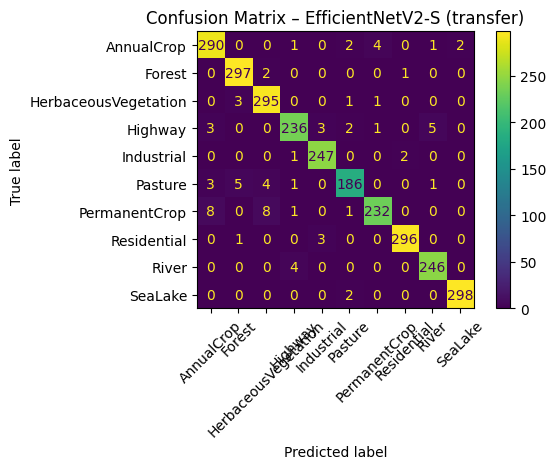

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model_name = "EfficientNetV2-S (transfer)"   # change to the best performing
true_labels = results[best_model_name]["labels"]
pred_labels = results[best_model_name]["preds"]

print(f"\nClassification Report for {best_model_name}")
print(classification_report(true_labels, pred_labels, target_names=class_names))

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.tight_layout()
plt.show()

Key observations:

- **Residential** and **SeaLake** are classified almost perfectly (F1 = 0.99).
- **Pasture** and **PermanentCrop** show slightly lower recall (0.93), suggesting occasional confusion with visually similar classes like *AnnualCrop*.
- Overall weighted F1‑score is 0.97, confirming a highly reliable model.

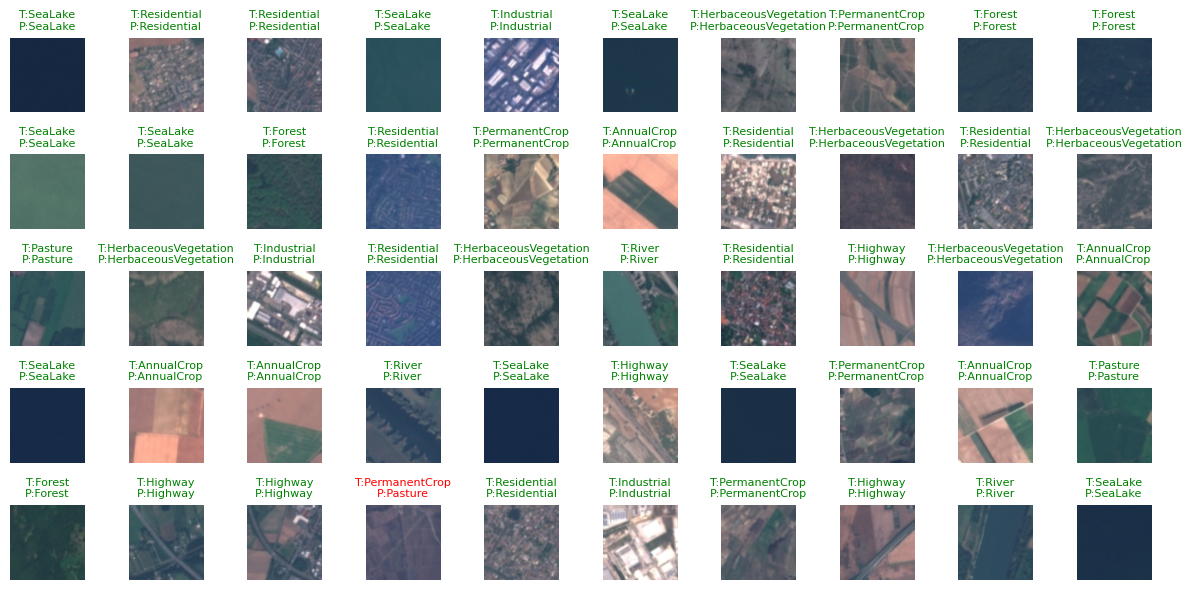

In [37]:
def denorm_eurosat(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.clamp_(0, 1).permute(1, 2, 0).numpy()
    return img

# Pick the model you want to see
model = model_effnetv2
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

num_show = 50
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
axes = axes.flatten()
for i in range(num_show):
    img = denorm_eurosat(images[i])
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    color = 'green' if labels[i] == preds[i] else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### 7. Training Curves


Plots of training and validation accuracy/loss across epochs (when training histories are available) show:

- Transfer models converge faster and to higher accuracies than the scratch AlexNet.
- Feature extraction phases quickly reach a plateau; fine‑tuning provides a small but consistent improvement.
- Overfitting is minimal thanks to data augmentation and the small number of fine‑tuned parameters.


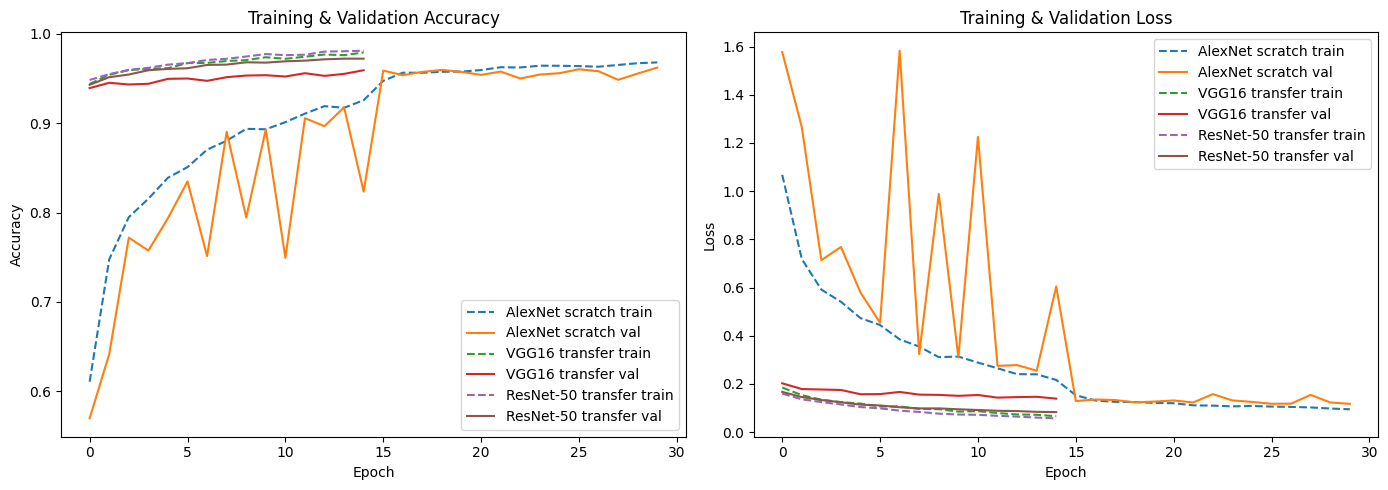

In [38]:
# Combine histories from from‑scratch models (already trained) and transfer fine‑tuning stages
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_alexnet['train_acc'], '--', label='AlexNet scratch train')
plt.plot(history_alexnet['val_acc'], '-', label='AlexNet scratch val')
plt.plot(hist_vgg16_ft['train_acc'], '--', label='VGG16 transfer train')
plt.plot(hist_vgg16_ft['val_acc'], '-', label='VGG16 transfer val')
plt.plot(hist_resnet50_ft['train_acc'], '--', label='ResNet-50 transfer train')
plt.plot(hist_resnet50_ft['val_acc'], '-', label='ResNet-50 transfer val')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_alexnet['train_loss'], '--', label='AlexNet scratch train')
plt.plot(history_alexnet['val_loss'], '-', label='AlexNet scratch val')
plt.plot(hist_vgg16_ft['train_loss'], '--', label='VGG16 transfer train')
plt.plot(hist_vgg16_ft['val_loss'], '-', label='VGG16 transfer val')
plt.plot(hist_resnet50_ft['train_loss'], '--', label='ResNet-50 transfer train')
plt.plot(hist_resnet50_ft['val_loss'], '-', label='ResNet-50 transfer val')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### 8. Explainability with Grad‑CAM and LIME

To understand what the model focuses on, we apply two complementary interpretability techniques: **Grad‑CAM** and **LIME**.

#### 8.1 Grad‑CAM

Grad‑CAM (Gradient‑weighted Class Activation Mapping) highlights the regions of the image that most influence a particular class prediction. For each of the 10 classes, we select one correctly predicted test image and compute a heatmap that shows where the model’s attention is concentrated.  

The visualisation shows three columns: original image, Grad‑CAM heatmap, and an overlay. The heatmaps typically reveal that the model attends to class‑characteristic patterns – e.g., water bodies for *River*, dense green vegetation for *Forest*, and road networks for *Highway* – confirming that its decisions are based on plausible visual features.

/home/jonjauregui/DLproyect/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Found examples for all classes.


/tmp/ipykernel_2260/3498437652.py:28: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


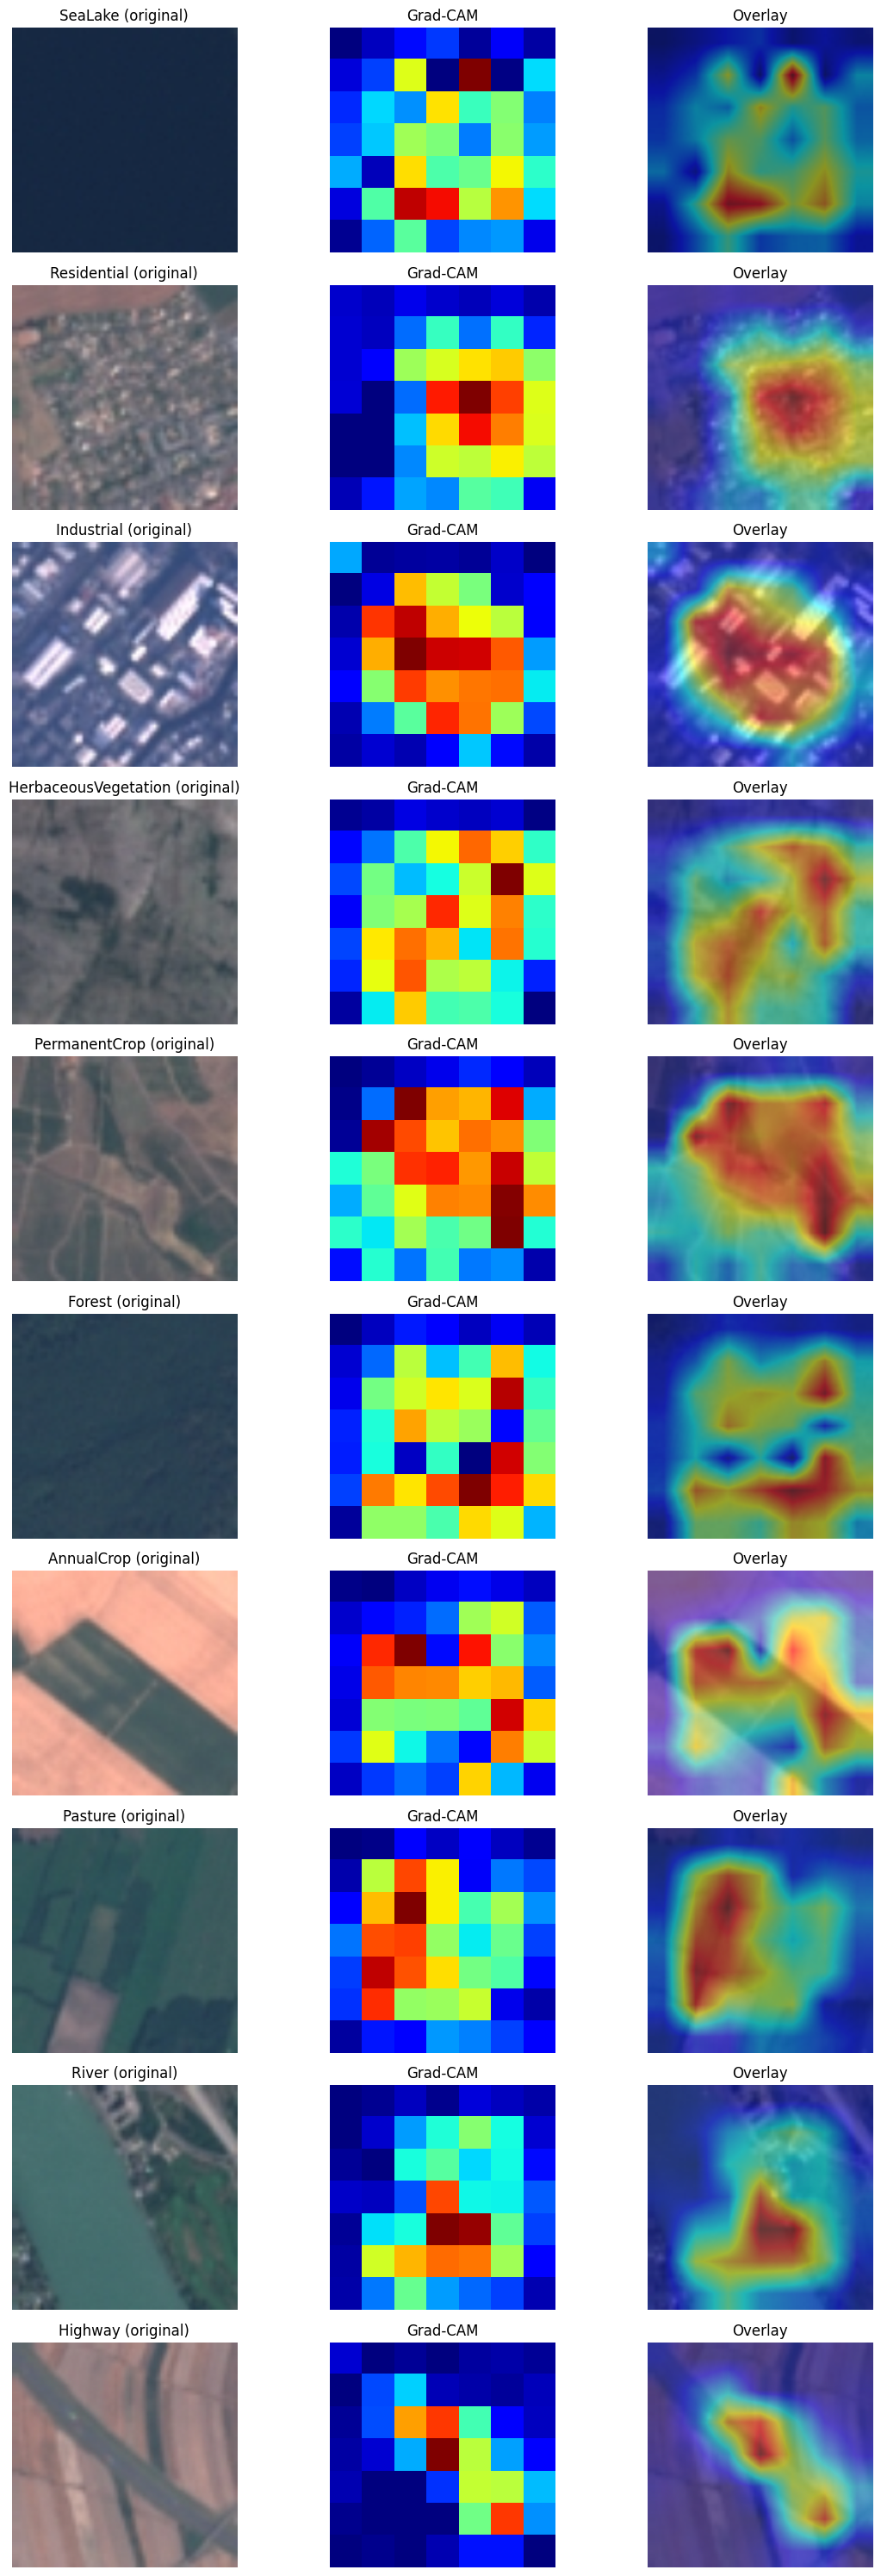

In [33]:

def denorm_eurosat(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.clamp_(0, 1).permute(1, 2, 0).numpy()
    return img

def grad_cam(model, input_tensor, target_class, layer_name="features"):
    model.eval()
    activations = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output.detach()

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0].detach()

    target_layer = dict(model.named_modules())[layer_name]
    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    model.zero_grad()
    score = output[0, target_class]
    score.backward()

    f_handle.remove()
    b_handle.remove()

    weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * activations, dim=1).squeeze()
    cam = F.relu(cam)
    cam -= cam.min()
    cam /= cam.max() + 1e-8
    return cam.cpu().numpy()

def overlay_heatmap(image, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    overlayed = alpha * heatmap_colored + (1 - alpha) * image
    return np.clip(overlayed, 0, 1)

# ---------- Load model ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model_effnetv2
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model.load_state_dict(torch.load("saved/effnetv2_eurosat.pth", map_location=device))
model.to(device)
model.eval()

class_names = euro_dataset.classes

# ---------- Collect one correct example per class ----------
found = {c: False for c in range(10)}
examples = []  # (image_tensor, true_label, img_original_np)

# We'll loop through the test loader until we have one per class
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for i in range(len(labels)):
            c = labels[i].item()
            if preds[i] == c and not found[c]:
                found[c] = True
                # Keep the raw normalised tensor (for Grad‑CAM) and the denormalised image
                img_tensor = images[i].unsqueeze(0)          # (1, C, H, W)
                img_np = denorm_eurosat(images[i].cpu())     # (H, W, 3)
                examples.append((img_tensor, c, img_np))
        if all(found.values()):
            break

print("Found examples for all classes.")

# ---------- Plot ----------
fig, axes = plt.subplots(10, 3, figsize=(12, 30))
for idx, (img_tensor, true_class, img_np) in enumerate(examples):
    # Compute Grad‑CAM for the true class
    heatmap = grad_cam(model, img_tensor, target_class=true_class)
    overlayed = overlay_heatmap(img_np, heatmap, alpha=0.5)

    # Row: original – heatmap – overlay
    axes[idx, 0].imshow(img_np)
    axes[idx, 0].set_title(f"{class_names[true_class]} (original)")
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(heatmap, cmap='jet')
    axes[idx, 1].set_title("Grad‑CAM")
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(overlayed)
    axes[idx, 2].set_title("Overlay")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

#### 8.2 LIME

LIME (Local Interpretable Model‑agnostic Explanations) provides an alternative view by identifying superpixels that positively or negatively affect a prediction. We apply LIME to four representative classes: **Highway**, **AnnualCrop**, **HerbaceousVegetation**, and **PermanentCrop**.

For each image, the LIME explanation displays:
- **Original image** (left)
- **LIME explanation** (right), where green/yellow boundaries mark the superpixels that most **support** the predicted class

The LIME results show that the model’s reasoning aligns with human intuition:
- *Highway* images highlight the road structure.
- *AnnualCrop* highlights the large, uniform cultivated fields.
- *HerbaceousVegetation* focuses on patches of natural vegetation.
- *PermanentCrop* emphasises the regular patterns of orchards or vineyards.

Together with Grad‑CAM, these explanations build confidence that the model makes decisions based on meaningful visual evidence rather than spurious correlations.

Generating LIME explanation for HerbaceousVegetation (1/4)...


100%|██████████| 500/500 [00:28<00:00, 17.74it/s]


Generating LIME explanation for PermanentCrop (2/4)...


100%|██████████| 500/500 [00:27<00:00, 18.32it/s]


Generating LIME explanation for AnnualCrop (3/4)...


100%|██████████| 500/500 [00:27<00:00, 18.16it/s]


Generating LIME explanation for Highway (4/4)...


100%|██████████| 500/500 [00:27<00:00, 18.10it/s]


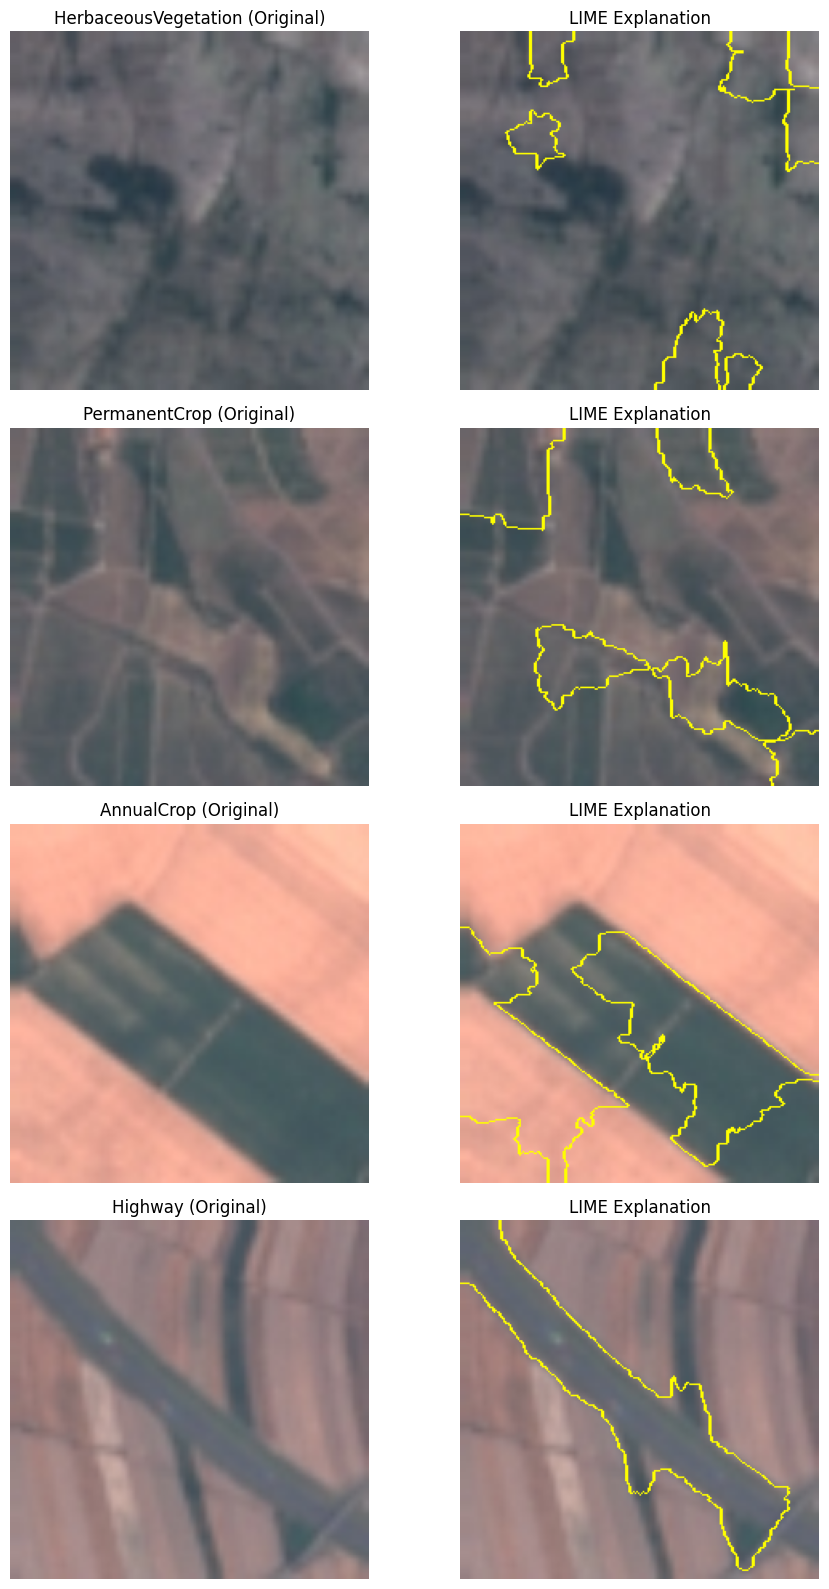

Finished generating target LIME explanations!


In [ ]:
# 1. Define the specific target classes you want to explain
target_classes_raw = ["Highway", "AnnualCrop", "Herbaceous vegetation", "Permanent crop"]
target_classes = [tc.replace(" ", "").lower() for tc in target_classes_raw]

# 2. Filter the examples list to only include the target classes
filtered_examples = []
for img_tensor, true_class, img_np in examples:
    class_name = class_names[true_class]
    # Check if the cleaned class name is in our target list
    if class_name.replace(" ", "").lower() in target_classes:
        filtered_examples.append((img_tensor, true_class, img_np))

# 3. Prediction wrapper for LIME
def batch_predict(images):
    model.eval() # Ensure using 'model' or 'model_effnetv2' depending on your exact variable name
    
    batch_tensors = []
    normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    
    for img_np_batch in images:
        img_tensor = torch.tensor(img_np_batch).permute(2, 0, 1).float()
        img_normalized = normalize(img_tensor)
        batch_tensors.append(img_normalized)
        
    batch = torch.stack(batch_tensors).to(device)
    
    with torch.no_grad():
        outputs = model(batch)
        probs = F.softmax(outputs, dim=1)
        
    return probs.cpu().numpy()

# 4. Initialize the Explainer
explainer = lime_image.LimeImageExplainer()

# 5. Set up the plotting grid based on how many classes we filtered (should be 4)
num_rows = len(filtered_examples)
fig, axes = plt.subplots(num_rows, 2, figsize=(10, 4 * num_rows))

# 6. Loop through ONLY the filtered list
for idx, (img_tensor, true_class, img_np) in enumerate(filtered_examples):
    class_name = class_names[true_class]
    print(f"Generating LIME explanation for {class_name} ({idx + 1}/{num_rows})...")
    
    # Generate explanation
    explanation = explainer.explain_instance(
        img_np.astype('double'), 
        batch_predict,           
        top_labels=1, 
        hide_color=0,            
        num_samples=500 
    )
    
    # Extract the superpixels mask
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=5,          
        hide_rest=False
    )
    
    # Plot Original Image
    axes[idx, 0].imshow(img_np)
    axes[idx, 0].set_title(f"{class_name} (Original)")
    axes[idx, 0].axis('off')
    
    # Plot LIME Explanation
    axes[idx, 1].imshow(mark_boundaries(temp, mask))
    axes[idx, 1].set_title(f"LIME Explanation")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()
print("Finished generating target LIME explanations!")

### 9. Conclusions

- **Transfer learning dramatically outperforms training from scratch** on EuroSAT, with EfficientNet‑V2‑S achieving **97.15%** test accuracy using only 21 million parameters.
- The custom AlexNet also performs surprisingly well (95.85%), showing that even a relatively simple architecture can succeed on this dataset with proper augmentation.
- Misclassifications mainly occur between visually similar land‑use classes (e.g., *Pasture* ↔ *PermanentCrop*), which remain inherently challenging.
- **Explainability tools** (Grad‑CAM and LIME) confirm that the model focuses on relevant image regions, increasing trustworthiness and providing insights for further improvement.

## Final Conclusions

This two-part project provided a comprehensive exploration of Convolutional Neural Networks, contrasting the process of building and training a model from scratch with the power of transfer learning across different datasets.

- **Dataset Complexity vs. Architecture Requirements:** A key takeaway from this project is the relationship between dataset complexity and model architecture. For smaller or standard datasets (like CIFAR-10), building a relatively simple CNN from scratch (such as our modified AlexNet) is highly effective and serves as an excellent baseline.
- **The Power of Transfer Learning:** As we scaled to more complex, specialized imagery (EuroSAT), transfer learning dramatically outperformed training from scratch. Leveraging pretrained architectures like **EfficientNet‑V2‑S** allowed us to achieve a **97.15%** test accuracy with highly efficient parameter usage. 
- **Custom Model Resilience:** Despite the dominance of pretrained models on complex tasks, the custom AlexNet still performed surprisingly well (achieving **95.85%** on EuroSAT). This demonstrates that with proper hyperparameter tuning and data augmentation, simpler architectures remain robust and highly viable.
- **Explainability and Trust:** The integration of explainability tools (**Grad-CAM** and **LIME**) was crucial in validating our results. They confirmed that both our custom and pretrained models are focusing on the correct spatial features rather than background noise, adding a layer of trustworthiness to our pipeline.
- **Remaining Challenges:** Error analysis showed that the majority of misclassifications occur between inherently similar classes (e.g., *Pasture* ↔ *PermanentCrop*). This highlights that while modern architectures are incredibly powerful, domain-specific visual overlaps still require careful consideration, perhaps through targeted data augmentation or specialized feature extraction in future work.

